# Week 5: Handling Imbalanced & Messy Real-World Data

This project focuses on handling class imbalance using the Telco Customer Churn dataset.

The target variable is Churn, which indicates whether a customer left the company.

The class distribution is analyzed and visualized before applying class weighting to address imbalance.

Model performance is compared before and after handling class imbalance using Precision, Recall, and F1-score.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

print("Missing TotalCharges:")
print(df['TotalCharges'].isnull().sum())

Missing TotalCharges:
0


In [9]:
print("Churn Distribution:")
print(df['Churn'].value_counts())

print("\nChurn Percentage:")
print(
    df['Churn'].value_counts(normalize=True) * 100
)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


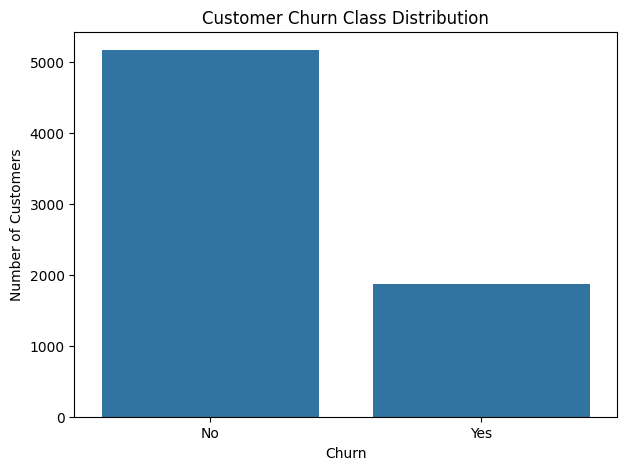

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title('Customer Churn Class Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

## Class Imbalance

The target variable Churn contains two classes: customers who stayed and customers who churned.

The dataset is imbalanced because the number of customers who stayed is higher than the number of customers who churned.

This imbalance can cause a machine learning model to favor the majority class.

Therefore, accuracy alone may not provide a complete picture of model performance, especially when correctly identifying churned customers is important for the business.

In [11]:
# Convert Churn to binary values
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

y = df['Churn']

print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [12]:
features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'InternetService',
    'PaymentMethod',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]

X = df[features]

print(X.head())

   tenure  MonthlyCharges  TotalCharges        Contract InternetService  \
0       1           29.85         29.85  Month-to-month             DSL   
1      34           56.95       1889.50        One year             DSL   
2       2           53.85        108.15  Month-to-month             DSL   
3      45           42.30       1840.75        One year             DSL   
4       2           70.70        151.65  Month-to-month     Fiber optic   

               PaymentMethod  SeniorCitizen Partner Dependents  
0           Electronic check              0     Yes         No  
1               Mailed check              0      No         No  
2               Mailed check              0      No         No  
3  Bank transfer (automatic)              0      No         No  
4           Electronic check              0      No         No  


In [13]:
X = pd.get_dummies(
    X,
    columns=[
        'Contract',
        'InternetService',
        'PaymentMethod',
        'Partner',
        'Dependents'
    ],
    drop_first=True
)

print("Encoded Features:")
print(X.columns.tolist())

Encoded Features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Partner_Yes', 'Dependents_Yes']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 5634
Testing Samples: 1409


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [16]:
original_model = LogisticRegression(
    max_iter=1000
)

original_model.fit(
    X_train_scaled,
    y_train
)

original_pred = original_model.predict(
    X_test_scaled
)

In [17]:
original_accuracy = accuracy_score(
    y_test,
    original_pred
)

original_precision = precision_score(
    y_test,
    original_pred
)

original_recall = recall_score(
    y_test,
    original_pred
)

original_f1 = f1_score(
    y_test,
    original_pred
)

print("===== ORIGINAL MODEL =====")
print("Accuracy:", round(original_accuracy, 4))
print("Precision:", round(original_precision, 4))
print("Recall:", round(original_recall, 4))
print("F1-score:", round(original_f1, 4))

===== ORIGINAL MODEL =====
Accuracy: 0.7956
Precision: 0.6335
Recall: 0.5455
F1-score: 0.5862


In [18]:
print(
    classification_report(
        y_test,
        original_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [19]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

balanced_model.fit(
    X_train_scaled,
    y_train
)

balanced_pred = balanced_model.predict(
    X_test_scaled
)

In [20]:
balanced_accuracy = accuracy_score(
    y_test,
    balanced_pred
)

balanced_precision = precision_score(
    y_test,
    balanced_pred
)

balanced_recall = recall_score(
    y_test,
    balanced_pred
)

balanced_f1 = f1_score(
    y_test,
    balanced_pred
)

print("===== BALANCED MODEL =====")
print("Accuracy:", round(balanced_accuracy, 4))
print("Precision:", round(balanced_precision, 4))
print("Recall:", round(balanced_recall, 4))
print("F1-score:", round(balanced_f1, 4))

===== BALANCED MODEL =====
Accuracy: 0.7374
Precision: 0.5034
Recall: 0.7968
F1-score: 0.617


In [21]:
print(
    classification_report(
        y_test,
        balanced_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [22]:
comparison = pd.DataFrame({
    'Model': [
        'Original Logistic Regression',
        'Balanced Logistic Regression'
    ],
    'Accuracy': [
        original_accuracy,
        balanced_accuracy
    ],
    'Precision': [
        original_precision,
        balanced_precision
    ],
    'Recall': [
        original_recall,
        balanced_recall
    ],
    'F1-score': [
        original_f1,
        balanced_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Original Logistic Regression,0.795600,0.633540,0.545455,0.586207
1,Balanced Logistic Regression,0.737402,0.503378,0.796791,0.616977


In [23]:
comparison.style.format({
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1-score': '{:.2%}'
})

,Model,Accuracy,Precision,Recall,F1-score
0,Original Logistic Regression,79.56%,63.35%,54.55%,58.62%
1,Balanced Logistic Regression,73.74%,50.34%,79.68%,61.70%


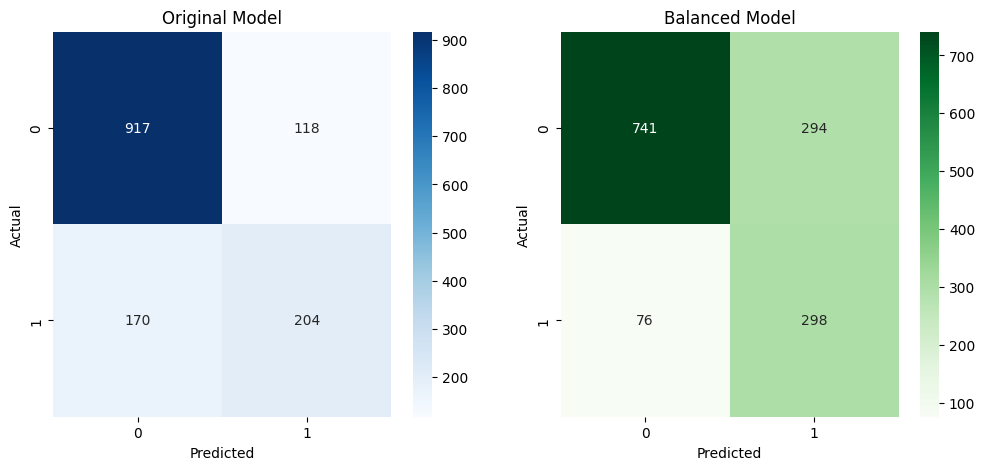

In [24]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Original model
cm_original = confusion_matrix(
    y_test,
    original_pred
)

sns.heatmap(
    cm_original,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title(
    'Original Model'
)

axes[0].set_xlabel(
    'Predicted'
)

axes[0].set_ylabel(
    'Actual'
)


# Balanced model
cm_balanced = confusion_matrix(
    y_test,
    balanced_pred
)

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)

axes[1].set_title(
    'Balanced Model'
)

axes[1].set_xlabel(
    'Predicted'
)

axes[1].set_ylabel(
    'Actual'
)

plt.show()

In [25]:
recall_improvement = (
    balanced_recall - original_recall
) * 100

print(
    "Recall Improvement:",
    round(recall_improvement, 2),
    "percentage points"
)

Recall Improvement: 25.13 percentage points


## Why Accuracy Can Be Misleading

Accuracy alone can be misleading when dealing with imbalanced datasets because a model may achieve a relatively high accuracy by mainly predicting the majority class. In this churn dataset, the original model achieved **79.56% accuracy**, but its recall for the churn class was only **54.55%**, meaning it missed many customers who actually churned. After applying class weighting, accuracy decreased to **73.74%**, but recall increased significantly to **79.68%**. This shows that accuracy does not always represent the usefulness of a model. For customer churn prediction, Precision, Recall, and F1-score are important because the business needs to identify customers who are at risk of leaving.


## Final Analysis

The original Logistic Regression model achieved an accuracy of **79.56%**, with a precision of **63.35%**, recall of **54.55%**, and F1-score of **58.62%**. After applying `class_weight='balanced'`, accuracy decreased to **73.74%**, while recall increased significantly to **79.68%**. This represents an improvement of **25.13 percentage points in recall**, meaning the balanced model was able to identify a much larger proportion of customers who actually churned. Although the balanced model produced more false positives and lower precision, improving recall can be valuable in customer churn applications because missing a customer who is likely to leave can result in lost revenue. Therefore, the balanced model provides a better approach when the business priority is to identify as many potential churn customers as possible.


## Conclusion

This project demonstrated the importance of handling class imbalance in real-world machine learning problems. A Logistic Regression model was first trained on the original imbalanced dataset and then retrained using `class_weight='balanced'`. The balanced model reduced accuracy from **79.56% to 73.74%**, but significantly improved recall from **54.55% to 79.68%**. This 25.13 percentage-point improvement in recall means that the balanced model identified many more customers who were actually likely to churn. The results demonstrate that model evaluation should consider multiple metrics rather than relying only on accuracy, especially when correctly identifying the minority class is important for business decisions.
